# In-Class Competition: TikTok Video Engagement Prediction (Day 30 Views)

**Goal:** Predict each video's cumulative view count at Day 30 using only information available during the first five days after posting.

**Evaluation metric:** RMSE on the original view-count scale.

**Modeling approach:** feature engineering → target transformation → repeated cross-validation → model comparison → equal-weight ensemble → final submission.

# 1. Data Exploration 📊

First inspect the video, engagement, and creator tables and check the availability of the Day 0–5 engagement window.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
SEED = 42
DATA_DIR = 'data'

train = pd.read_csv('train_videos.csv')
test = pd.read_csv('test_videos.csv')
engagement = pd.read_csv('engagement_daily.csv')
creators = pd.read_csv('creators_daily.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print('train:', train.shape)
print('test:', test.shape)
print('engagement:', engagement.shape)
print('creators:', creators.shape)

train: (12000, 27)
test: (3001, 26)
engagement: (79489, 10)
creators: (252166, 7)


In [41]:
display(train.head())

,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,...,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear,target_day30_views
0,7389777708642798891,6823500943611528198,2024-07-09 18:11:50,2024-07-09,61.230,540p,en,1,0.0,0,...,4.0,6.532745,Lifestyle,0.003960,0.790962,0.017963,0.002873,0.004761,0.001092,1371
1,7414315783221693739,6851716737763886085,2024-09-13 21:12:02,2024-09-13,58.095,540p,en,1,0.0,0,...,6.0,4.148378,Beauty_Fashion,0.004058,0.767556,0.003882,0.012160,0.019463,0.001298,1184
2,7408397785503943942,6809119722295968773,2024-08-28 22:27:16,2024-08-28,7.431,720p,en,1,0.0,0,...,4.0,0.000000,Life_hacks_Personal_growth,0.003275,0.849156,0.003241,0.007868,0.005667,0.003849,638
3,7406460852611681567,6790225026127627269,2024-08-23 17:11:01,2024-08-23,15.046,540p,un,0,0.0,0,...,0.0,0.000000,Beauty_Fashion,0.004971,0.612373,0.006764,0.010911,0.066338,0.001878,312
4,7428770082219756831,2033984,2024-10-22 20:02:15,2024-10-22,7.895,540p,en,1,0.0,0,...,NaN,NaN,Beauty_Fashion,0.022163,0.006064,0.008672,0.041306,0.474281,0.022709,180


In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   video_id             12000 non-null  int64  
 1   author_id            12000 non-null  int64  
 2   create_time          12000 non-null  object 
 3   create_date          12000 non-null  object 
 4   duration             12000 non-null  float64
 5   ratio                12000 non-null  object 
 6   desc_language        12000 non-null  object 
 7   is_english           12000 non-null  int64  
 8   created_by_ai        12000 non-null  float64
 9   is_ads               12000 non-null  int64  
 10  music_selected_from  11879 non-null  object 
 11  music_author         11979 non-null  object 
 12  music_owner_id       9028 non-null   float64
 13  music_id             11999 non-null  float64
 14  word_count           7953 non-null   float64
 15  emoji_count          7953 non-null  

In [43]:
# engagement_daily has the day-by-day stats for each video (day 0 to day 5 only, as the rules say)
print(engagement['days_since_post'].unique())
display(engagement.head())

[0 1 2 3 4 5]


,video_id,date,days_since_post,play_count,like_count,comment_count,share_count,collect_count,download_count,whatsapp_share_count
0,7384086821132717358,2024-06-24,0,105696,6249,23,1113,1737,59,5
1,7384086821132717358,2024-06-25,1,330084,25291,71,3689,6421,214,25
2,7384086821132717358,2024-06-26,2,390753,32925,93,4476,8082,272,30
3,7384086821132717358,2024-06-27,3,464862,45741,137,5756,10699,358,33
4,7384086821132717358,2024-06-28,4,475386,46896,143,5907,10926,366,33


In [44]:
display(creators.head())

,author_id,date,follower_count,following_count,total_favorited,video_count,enterprise_verified
0,10245051,2024-06-27,1704.0,1039.0,75987,83.0,NaN
1,10245051,2024-06-28,1704.0,1039.0,76018,83.0,NaN
2,10245051,2024-06-29,1704.0,1039.0,76024,83.0,NaN
3,10245051,2024-06-30,1704.0,1039.0,76025,83.0,NaN
4,10245051,2024-07-01,1704.0,1039.0,76029,83.0,NaN


### Engagement coverage check

The engagement table does not contain all six days for every video. There are 79,489 engagement rows instead of roughly 15,001 × 6 = 90,006 expected rows. We therefore check day availability before building time-based features.

In [45]:
n_videos = len(train) + len(test)
print('videos that appear in the engagement table:', engagement['video_id'].nunique(), 'out of', n_videos)

coverage = (engagement.groupby('days_since_post')['video_id'].nunique() / n_videos).round(3)
display(coverage.rename('share of videos that have this day').to_frame())

videos that appear in the engagement table: 15000 out of 15001


,share of videos that have this day
days_since_post,
0,0.376
1,0.983
2,0.982
3,0.984
4,0.990
5,0.983


### Key data-quality insight

Day 0 is available for only about 38% of videos, while Days 1–5 are available for about 98%. Therefore, features should **not depend on Day 0**. We build engagement features from Days 1–5 and use the **last available day** for each video. This keeps the feature construction consistent and avoids discarding most of the training data.

###A quick look at the target: `target_day30_views`. The competition PDF warned us this follows a power law (a few videos go viral, most don't), so let's see it for ourselves.

In [46]:
train['target_day30_views'].describe()

,target_day30_views
count,1.200000e+04
mean,2.922860e+04
std,2.752131e+05
min,0.000000e+00
25%,3.440000e+02
50%,6.680000e+02
75%,3.016500e+03
max,1.631055e+07


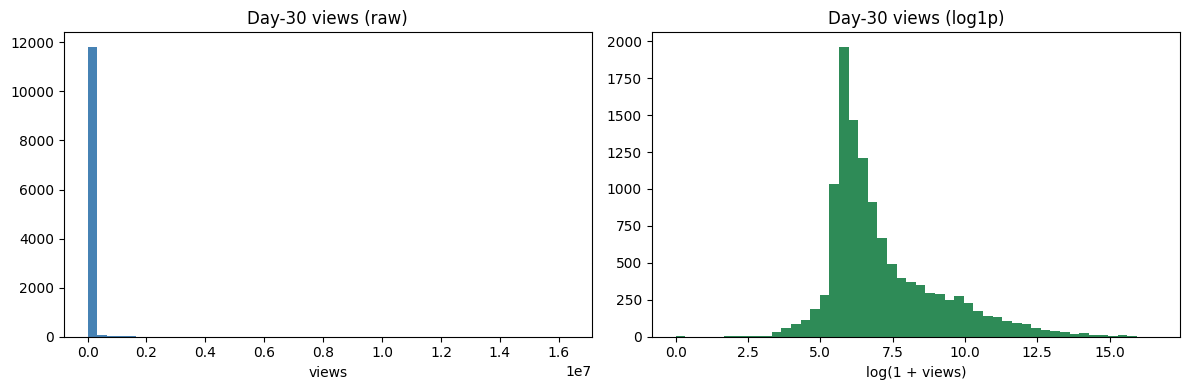

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['target_day30_views'], bins=50, color='steelblue')
axes[0].set_title('Day-30 views (raw)')
axes[0].set_xlabel('views')

axes[1].hist(np.log1p(train['target_day30_views']), bins=50, color='seagreen')
axes[1].set_title('Day-30 views (log1p)')
axes[1].set_xlabel('log(1 + views)')

plt.tight_layout()
plt.show()

###The raw histogram is basically one giant bar near zero with a long invisible tail - that's the power law the PDF talked about. Once we take `log1p`, the distribution looks much closer to normal, so our first target will be `log1p(target_day30_views)`.
###Because the score is RMSE on the **raw** views, the viral videos matter far more than the rest. Let's measure how much:

In [48]:
t_sorted = train['target_day30_views'].sort_values(ascending=False).values
sq = t_sorted.astype('float64') ** 2
print(f'top 10 videos  = {sq[:10].sum() / sq.sum():.1%} of the total squared views')
print(f'top 50 videos  = {sq[:50].sum() / sq.sum():.1%} of the total squared views')

top 10 videos  = 66.3% of the total squared views
top 50 videos  = 92.0% of the total squared views


###A handful of videos decide most of the raw RMSE. That has two consequences for the rest of the notebook: (1) a single validation split can look great or terrible just because of 2 or 3 viral videos, so we'll evaluate with **repeated cross-validation** and report several metrics; (2) predicting a viral video 3x too high is very expensive, so we prefer stable ensembles over one aggressive model.
###Another important property: the target is a **cumulative** view count, so at day 30 a video can never have fewer views than we already saw in the first 5 days. Let's check that on the training data:

In [49]:
play = engagement.pivot(index='video_id', columns='days_since_post', values='play_count')
last_seen = play[[1, 2, 3, 4, 5]].ffill(axis=1).bfill(axis=1)[5]       # views on the last available day (1-5)

chk = pd.DataFrame({'target': train.set_index('video_id')['target_day30_views'],
                    'last_seen': last_seen}).dropna()
print('share of videos where day-30 views >= views we already saw:', round((chk['target'] >= chk['last_seen']).mean(), 4))

growth = chk['target'] / chk['last_seen'].replace(0, np.nan)
display(growth.describe(percentiles=[.5, .9, .99]).round(2).to_frame('day30 views / last seen views'))

share of videos where day-30 views >= views we already saw: 0.9999


,day30 views / last seen views
count,11994.00
mean,1.63
std,10.17
min,0.00
50%,1.16
90%,1.69
99%,4.85
max,767.27


###So the target is (almost) never below the views we already know, and the typical video grows by only about 1.2x between day 5 and day 30. This gives us two tricks that we'll use later:
- **Clip every prediction** so it is never below the last views we observed.
- **Predict the growth multiple** (`log(target) - log(last views)`) as a second version of the target: it lets the model focus on "how much more will it grow?" instead of re-learning the size of the video.

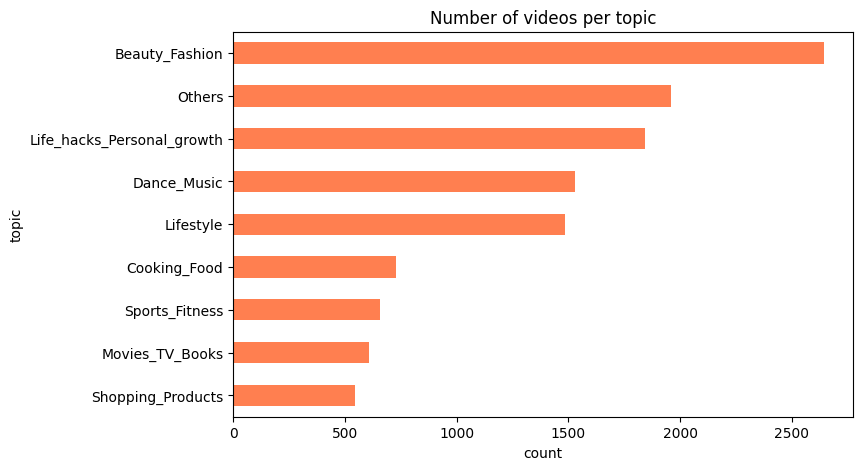

In [50]:
train['topic'].value_counts().plot(kind='barh', figsize=(8,5), color='coral')
plt.title('Number of videos per topic')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.show()

###Beauty_Fashion is by far the most common topic, followed by Others and Life_hacks_Personal_growth.
###Last check before cleaning: how many creators appear in both train and test?

In [51]:
train_creators, test_creators = set(train['author_id']), set(test['author_id'])
print('creators in train:', len(train_creators), '| in test:', len(test_creators))
print('creators in BOTH :', len(train_creators & test_creators))
print('share of test videos whose creator also appears in train:', round(test['author_id'].isin(train_creators).mean(), 3))

creators in train: 1607 | in test: 1115
creators in BOTH : 1051
share of test videos whose creator also appears in train: 0.975


### Creator overlap and validation choice

Almost all test videos belong to creators that also appear in the training data. Because the test set has substantial creator overlap, a shuffled random K-fold split is the main validation strategy. We also run GroupKFold by creator as a stricter robustness check.

This is a validation choice based on the observed train/test structure, not a claim that creator information is available after the prediction date.

# 2. Data Cleaning 🧹

Check duplicates, missing values, data types, and categorical values. Missing numeric values are retained where the model can handle them natively; preprocessing for models that require complete numeric input is performed inside the modeling pipeline.

In [52]:
print('Missing values in train:')
print(train.isna().sum()[train.isna().sum() > 0])

Missing values in train:
music_selected_from     121
music_author             21
music_owner_id         2972
music_id                  1
word_count             4047
emoji_count            4047
question_count         4047
hashtag_count          4047
speaking_rate          4047
anger                    42
joy                      42
surprise                 42
sadness                  42
disgust                  42
fear                     42
dtype: int64


In [53]:
print('Duplicate video_id in train:', train['video_id'].duplicated().sum())
print('Duplicate video_id in test:', test['video_id'].duplicated().sum())

Duplicate video_id in train: 0
Duplicate video_id in test: 0


In [54]:
# categorical columns with missing values -> 'unknown'
cat_missing = ['ratio', 'desc_language', 'music_selected_from', 'topic']
for df in [train, test]:
    for c in cat_missing:
        df[c] = df[c].fillna('unknown')

print('Missing categorical values left:', train[cat_missing].isna().sum().sum(), test[cat_missing].isna().sum().sum())

Missing categorical values left: 0 0


###No duplicate `video_id`s, so nothing to drop. Categorical columns get an `'unknown'` label.
### Now each model handles missing values in the way it prefers: LightGBM and CatBoost read NaN directly, and the Random Forest and Ridge pipelines fill them **inside** the model, so nothing is learned from the validation rows.

# 3. Feature Engineering 🛠️

Most of the predictive signal should come from the early engagement pattern. All engagement features use only Days 1–5, which are within the allowed historical window.

We create:
- **Last-available engagement:** views, likes, comments, shares, collects, downloads, and related metrics.
- **Snapshots and trends:** selected earlier-day values plus daily increments and growth patterns.
- **Interaction ratios:** likes/views, comments/views, shares/views, collects/views, downloads/views, and related engagement rates.
- **Creator features:** followers, following, historical favorites, video count, and verification information available for the creator.
- **Video metadata:** duration, resolution, language, topic, hashtags, speaking rate, and other provided metadata.

The goal is to describe both the current size of the audience and the quality/intensity of engagement without using any Day 30 information.

In [55]:
ENG_METRICS = ['play_count', 'like_count', 'comment_count', 'share_count',
               'collect_count', 'download_count', 'whatsapp_share_count']

def engagement_features(eng, video_ids):
    eng = eng[eng['video_id'].isin(video_ids)]
    out = pd.DataFrame(index=pd.Index(video_ids, name='video_id'))

    # one table per metric: rows = videos, columns = day 0..5 (NaN where a day is missing)
    tables = {m: eng.pivot(index='video_id', columns='days_since_post', values=m)
                    .reindex(index=out.index, columns=range(6)) for m in ENG_METRICS}
    play = tables['play_count']

    out['n_days_observed'] = play[[1, 2, 3, 4, 5]].notna().sum(axis=1)
    out['has_day0'] = play[0].notna().astype(int)
    out['play_day0'] = play[0]                      # stays NaN when day 0 is missing

    # last available value on days 1-5 (a missing day is filled from the previous day)
    last = {}
    for m in ENG_METRICS:
        t = tables[m][[1, 2, 3, 4, 5]].ffill(axis=1).bfill(axis=1)
        last[m] = t[5]
        out[f'{m}_last'] = t[5]
        out[f'{m}_d1'] = t[1]
        out[f'{m}_d3'] = t[3]

    f = play[[1, 2, 3, 4, 5]].ffill(axis=1).bfill(axis=1)
    for d in [2, 3, 4, 5]:
        out[f'play_inc_d{d}'] = f[d] - f[d - 1]                       # views added on day d
    out['play_growth_1_5'] = f[5] / f[1].replace(0, np.nan)
    out['play_growth_4_5'] = f[5] / f[4].replace(0, np.nan)
    out['play_growth_1_3'] = f[3] / f[1].replace(0, np.nan)
    # is the video still accelerating by day 5, or slowing down?
    out['inc_ratio_5_2'] = out['play_inc_d5'] / out['play_inc_d2'].replace(0, np.nan)
    out['inc_ratio_5_3'] = out['play_inc_d5'] / out['play_inc_d3'].replace(0, np.nan)

    # interaction ratios on the last available day
    views = last['play_count'].replace(0, np.nan)
    for m, name in [('like_count', 'like'), ('comment_count', 'comment'), ('share_count', 'share'),
                    ('collect_count', 'collect'), ('download_count', 'download'),
                    ('whatsapp_share_count', 'whatsapp')]:
        out[f'{name}_to_view'] = last[m] / views
    out['like_to_view_d1'] = out['like_count_d1'] / out['play_count_d1'].replace(0, np.nan)
    out['day1_share_of_last'] = out['play_count_d1'] / views

    return out.replace([np.inf, -np.inf], np.nan)


def creator_features(videos, creators_df):
    creators_df = creators_df.copy()
    creators_df['date'] = pd.to_datetime(creators_df['date'])
    v = videos[['video_id', 'author_id', 'create_date']].copy()
    v['create_date'] = pd.to_datetime(v['create_date'])

    merged = pd.merge_asof(
        v.sort_values('create_date'),
        creators_df.sort_values('date')[['author_id', 'date', 'follower_count', 'following_count',
                                          'total_favorited', 'video_count']],
        left_on='create_date', right_on='date', by='author_id', direction='backward'
    )
    merged = merged.rename(columns={
        'follower_count': 'creator_followers',
        'following_count': 'creator_following',
        'total_favorited': 'creator_total_favorited',
        'video_count': 'creator_video_count'
    })
    return merged[['video_id', 'creator_followers', 'creator_following',
                   'creator_total_favorited', 'creator_video_count']]


def video_meta_features(df):
    df = df.copy()
    df['create_time'] = pd.to_datetime(df['create_time'])
    df['post_hour'] = df['create_time'].dt.hour
    df['post_dayofweek'] = df['create_time'].dt.dayofweek
    df['post_month'] = df['create_time'].dt.month
    df['is_weekend'] = df['post_dayofweek'].isin([5, 6]).astype(int)
    df['text_missing'] = df['word_count'].isna().astype(int)      # word_count & co. are missing together

    keep = ['video_id', 'author_id', 'duration', 'ratio', 'desc_language', 'is_english',
            'created_by_ai', 'is_ads', 'music_selected_from', 'word_count', 'emoji_count',
            'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'anger', 'joy',
            'surprise', 'sadness', 'disgust', 'fear', 'post_hour', 'post_dayofweek',
            'post_month', 'is_weekend', 'text_missing']
    return df[keep]


def build_dataset(videos, eng, creators_df):
    meta = video_meta_features(videos)
    eng_f = engagement_features(eng, videos['video_id'].values).reset_index()
    cre_f = creator_features(videos, creators_df)

    out = meta.merge(eng_f, on='video_id', how='left').merge(cre_f, on='video_id', how='left')
    out['log_views_over_followers'] = np.log1p(out['play_count_last']) - np.log1p(out['creator_followers'])
    return out


train_feat = build_dataset(train, engagement, creators)
test_feat = build_dataset(test, engagement, creators)
assert (train_feat['video_id'].values == train['video_id'].values).all()
assert (test_feat['video_id'].values == test['video_id'].values).all()
train_feat['target_day30_views'] = train['target_day30_views'].values

print(train_feat.shape, test_feat.shape)
print('Columns with missing values (share of train rows):')
display(train_feat.isna().mean()[lambda s: s > 0].sort_values(ascending=False).round(3).to_frame('missing'))
display(train_feat.head())

(12000, 73) (3001, 72)
Columns with missing values (share of train rows):


,missing
play_day0,0.628
emoji_count,0.337
word_count,0.337
question_count,0.337
hashtag_count,0.337
speaking_rate,0.337
inc_ratio_5_2,0.042
inc_ratio_5_3,0.042
sadness,0.004
surprise,0.004


,video_id,author_id,duration,ratio,desc_language,is_english,created_by_ai,is_ads,music_selected_from,word_count,...,download_to_view,whatsapp_to_view,like_to_view_d1,day1_share_of_last,creator_followers,creator_following,creator_total_favorited,creator_video_count,log_views_over_followers,target_day30_views
0,7389777708642798891,6823500943611528198,61.230,540p,en,1,0.0,0,original,207.0,...,0.0,0.0,0.094624,0.453659,41301.0,1762.0,7328919,541.0,-3.695243,1371
1,7414315783221693739,6851716737763886085,58.095,540p,en,1,0.0,0,shoot_page_recommend_favourite,171.0,...,0.0,0.0,0.078978,0.764654,1375.0,2213.0,10247,271.0,-0.199622,1184
2,7408397785503943942,6809119722295968773,7.431,720p,en,1,0.0,0,edit_page_recommend,43.0,...,0.0,0.0,0.098726,0.828496,5091.0,171.0,41403,805.0,-2.595255,638
3,7406460852611681567,6790225026127627269,15.046,540p,un,0,0.0,0,shoot_page_recommend,0.0,...,0.0,0.0,0.089431,0.894545,54324.0,4326.0,55297,1191.0,-5.282339,312
4,7428770082219756831,2033984,7.895,540p,en,1,0.0,0,single_song,NaN,...,0.0,0.0,0.018072,0.948571,1911.0,3835.0,32010,4195.0,-2.385421,180


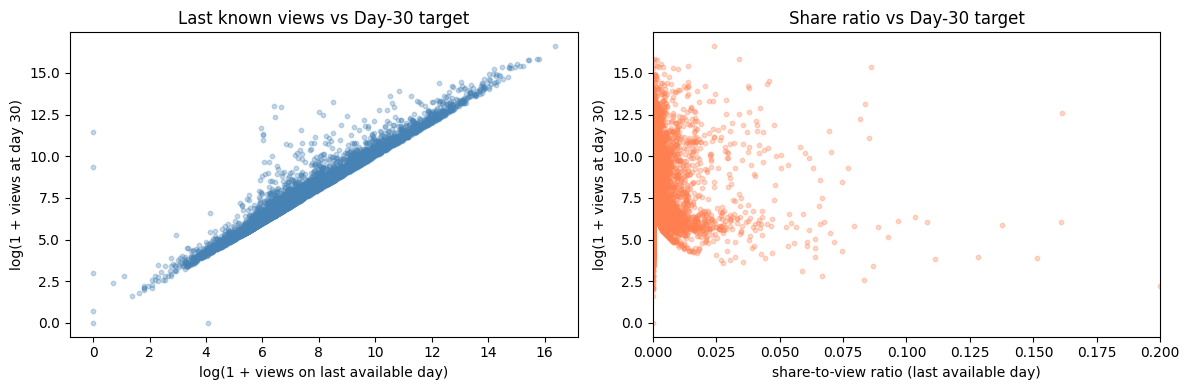

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(np.log1p(train_feat['play_count_last']), np.log1p(train_feat['target_day30_views']),
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('log(1 + views on last available day)')
axes[0].set_ylabel('log(1 + views at day 30)')
axes[0].set_title('Last known views vs Day-30 target')

axes[1].scatter(train_feat['share_to_view'], np.log1p(train_feat['target_day30_views']),
                alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('share-to-view ratio (last available day)')
axes[1].set_ylabel('log(1 + views at day 30)')
axes[1].set_title('Share ratio vs Day-30 target')
axes[1].set_xlim(0, 0.2)

plt.tight_layout()
plt.show()

### Feature insight

Early views are strongly related to Day 30 views, especially on the log scale. Engagement ratios add a different type of signal: for example, a higher share-to-view ratio indicates stronger sharing relative to the video's current audience. These features help the models distinguish videos with similar view counts but different engagement quality.

# 4. Target Transformation & Validation Strategy

The target is highly right-skewed: a small number of viral videos account for a large share of the squared error. We therefore evaluate models in three ways:

1. **Raw RMSE** — the actual competition metric and the primary selection criterion.
2. **Log RMSE** — a diagnostic metric that reduces the influence of extreme viral videos.
3. **Raw RMSE without the 10 most viral training videos** — a diagnostic view of typical-video performance.

For modeling, we test two target formulations:
- `log`: `log1p(Day30 views)`
- `growth`: `log1p(Day30 views) - log1p(last known views)`

The growth formulation asks the model to predict how much the video will continue growing after the last observed day.

In [57]:
from sklearn.model_selection import KFold, GroupKFold

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

y_raw = train_feat['target_day30_views'].values.astype('float64')
y_log = np.log1p(y_raw)

# views we already know on the last available day (used for the growth target and for clipping)
last_train = train_feat['play_count_last'].fillna(0).values
last_test = test_feat['play_count_last'].fillna(0).values
base_train, base_test = np.log1p(last_train), np.log1p(last_test)

X = train_feat.drop(columns=['target_day30_views', 'video_id', 'author_id'])
X_test = test_feat.drop(columns=['video_id', 'author_id'])
assert list(X.columns) == list(X_test.columns)

cat_cols = X.select_dtypes(exclude='number').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print('categorical columns:', cat_cols)
print('numeric columns:', len(num_cols))

# same category list for train and test (LightGBM needs this)
for c in cat_cols:
    cats = sorted(set(X[c].astype(str)) | set(X_test[c].astype(str)))
    X[c] = pd.Categorical(X[c].astype(str), categories=cats)
    X_test[c] = pd.Categorical(X_test[c].astype(str), categories=cats)

# ---- two versions of the target -------------------------------------------------------------
#  'log'    : log1p(day-30 views)
#  'growth' : log1p(day-30 views) - log1p(last known views)   -> "how much more will it grow?"
def y_target(mode):
    return y_log if mode == 'log' else y_log - base_train

def to_views(mode, pred, base):
    """model output -> predicted views"""
    return np.expm1(pred) if mode == 'log' else np.expm1(base + pred)

def finalize(views, last):
    """views can't be negative and can't be below the views we already saw"""
    return np.maximum(np.clip(views, 0, None), last)

# ---- metrics ----------------------------------------------------------------------------------
top10 = np.argsort(-y_raw)[:10]
mask_no_top10 = np.ones(len(y_raw), dtype=bool)
mask_no_top10[top10] = False

def score(views):
    return {'raw': rmse(y_raw, views),                                  # the competition metric
            'log': rmse(y_log, np.log1p(views)),                        # stable, less outlier-driven
            'no_top10': rmse(y_raw[mask_no_top10], views[mask_no_top10])}  # what the bulk of videos looks like

# ---- validation splits -------------------------------------------------------------------------
N_SEEDS = 2                                     # number of repeated 5-fold runs
splits = [list(KFold(5, shuffle=True, random_state=s).split(X)) for s in range(N_SEEDS)]

# one 80/20 hold-out, ONLY used to watch the training curves and to pick learning rate / number of trees
hold_tr, hold_va = splits[0][0]
print('hold-out:', len(hold_tr), 'train rows /', len(hold_va), 'validation rows')

categorical columns: ['ratio', 'desc_language', 'music_selected_from', 'topic']
numeric columns: 66
hold-out: 9600 train rows / 2400 validation rows


### Cross-validation

Use **repeated 5-fold cross-validation** with shuffled folds. Every training video receives an out-of-fold prediction, and the reported score is averaged across the repeated runs. This is more stable than relying on one 80/20 split, especially because a few viral videos can strongly affect raw RMSE.

A small 80/20 hold-out is used only for model-development tasks such as checking learning curves and selecting the number of trees/learning rate. It is not used as the final model-comparison score.

Because the test set has very high creator overlap with the training set, random K-fold is the primary validation scheme. GroupKFold by creator is reported separately as a stricter robustness check.

# 5. Modeling & Training 🤖

Compare models from different families so that the final ensemble can combine different modeling assumptions:

- **LightGBM:** nonlinear gradient boosting with efficient handling of tabular data and missing values.
- **Random Forest:** bagged decision trees that provide a different source of predictions from boosting.
- **Ridge Regression:** a simple linear baseline after appropriate preprocessing.
- **CatBoost:** an additional gradient-boosting model with native categorical-feature handling.

Evaluate both the `log` and `growth` targets where appropriate. The final model is selected from the validation results using **raw RMSE**, because that is the competition metric.

###**5.1 LightGBM** - quick learning-rate check + early stopping (up to 2000 trees, stop when the validation score doesn't improve for 50 rounds)

In [58]:
import lightgbm as lgb

def lgb_params(lr, seed=SEED):
    return dict(objective='regression', metric='rmse', learning_rate=lr, num_leaves=31,
                min_data_in_leaf=20, feature_fraction=0.8,
                bagging_fraction=0.8, bagging_freq=1,      # bagging_freq=1 is what actually switches row-subsampling on
                lambda_l2=1.0, seed=seed, verbosity=-1)

LGB_CFG, lr_rows = {}, []
for mode in ['log', 'growth']:
    y_mode = y_target(mode)
    for lr in tqdm([0.03, 0.05, 0.08], desc=f'LightGBM learning-rate check ({mode} target)'):
        dtr = lgb.Dataset(X.iloc[hold_tr], label=y_mode[hold_tr], categorical_feature=cat_cols)
        dva = lgb.Dataset(X.iloc[hold_va], label=y_mode[hold_va], reference=dtr, categorical_feature=cat_cols)
        booster = lgb.train(lgb_params(lr), dtr, num_boost_round=2000, valid_sets=[dva], valid_names=['val'],
                            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
        lr_rows.append((mode, lr, booster.best_iteration, booster.best_score['val']['rmse']))

lr_results_df = pd.DataFrame(lr_rows, columns=['target', 'learning_rate', 'best_iteration', 'val_rmse'])
display(lr_results_df)

for mode in ['log', 'growth']:
    best = lr_results_df[lr_results_df['target'] == mode].sort_values('val_rmse').iloc[0]
    LGB_CFG[mode] = dict(lr=float(best['learning_rate']), iters=int(best['best_iteration']))
print(LGB_CFG)

LightGBM learning-rate check (log target):   0%|          | 0/3 [00:00<?, ?it/s]

LightGBM learning-rate check (growth target):   0%|          | 0/3 [00:00<?, ?it/s]

,target,learning_rate,best_iteration,val_rmse
0,log,0.03,616,0.323367
1,log,0.05,376,0.323609
2,log,0.08,132,0.326892
3,growth,0.03,2000,0.326953
4,growth,0.05,2000,0.322403
5,growth,0.08,1996,0.321871


{'log': {'lr': 0.03, 'iters': 616}, 'growth': {'lr': 0.08, 'iters': 1996}}


###Now let's *watch* the best `log` configuration train: the printout shows the RMSE every 50 trees, and the plot shows when the validation curve stops improving (that's where early stopping cuts).

[50]	train's rmse: 0.513045	val's rmse: 0.530596
[100]	train's rmse: 0.273379	val's rmse: 0.347279
[150]	train's rmse: 0.234346	val's rmse: 0.332829
[200]	train's rmse: 0.216094	val's rmse: 0.32958
[250]	train's rmse: 0.202436	val's rmse: 0.327799
[300]	train's rmse: 0.190874	val's rmse: 0.326702
[350]	train's rmse: 0.181293	val's rmse: 0.325601
[400]	train's rmse: 0.172499	val's rmse: 0.325267
[450]	train's rmse: 0.16448	val's rmse: 0.324973
[500]	train's rmse: 0.157317	val's rmse: 0.324715
[550]	train's rmse: 0.150703	val's rmse: 0.323892
[600]	train's rmse: 0.144552	val's rmse: 0.32351
[650]	train's rmse: 0.138487	val's rmse: 0.323624


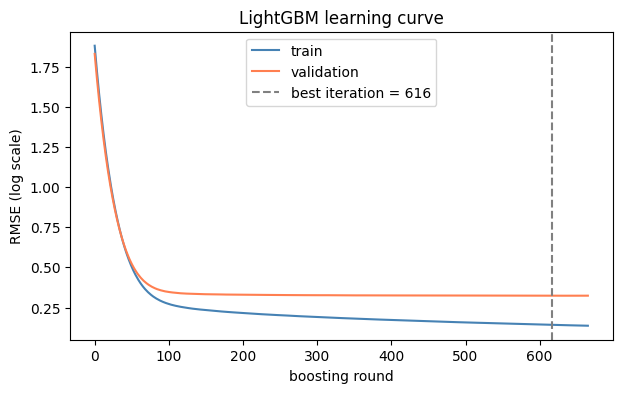

In [59]:
cfg = LGB_CFG['log']
y_mode = y_target('log')
dtr = lgb.Dataset(X.iloc[hold_tr], label=y_mode[hold_tr], categorical_feature=cat_cols)
dva = lgb.Dataset(X.iloc[hold_va], label=y_mode[hold_va], reference=dtr, categorical_feature=cat_cols)

lgb_curve = {}
lgb_watch = lgb.train(lgb_params(cfg['lr']), dtr, num_boost_round=2000, valid_sets=[dtr, dva],
                      valid_names=['train', 'val'],
                      callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                                 lgb.log_evaluation(period=50),
                                 lgb.record_evaluation(lgb_curve)])

plt.figure(figsize=(7, 4))
plt.plot(lgb_curve['train']['rmse'], label='train', color='steelblue')
plt.plot(lgb_curve['val']['rmse'], label='validation', color='coral')
plt.axvline(lgb_watch.best_iteration, color='gray', linestyle='--', label=f'best iteration = {lgb_watch.best_iteration}')
plt.xlabel('boosting round'); plt.ylabel('RMSE (log scale)'); plt.title('LightGBM learning curve')
plt.legend(); plt.show()

The training RMSE became much lower than the validation RMSE, showing clear overfitting. Early stopping helped prevent unnecessary training.

###**5.2 Random Forest** - Grow it 25 trees at a time (`warm_start`) and check the validation error after each step, to see when adding more trees stops helping.

Random Forest - growing the forest:   0%|          | 0/8 [00:00<?, ?it/s]

,0,1,2,3,4,5,6,7
n_trees,25.0000,50.0000,75.0000,100.000,125.0000,150.0000,175.0000,200.0000
val_rmse,0.3256,0.3233,0.3233,0.324,0.3237,0.3236,0.3237,0.3238


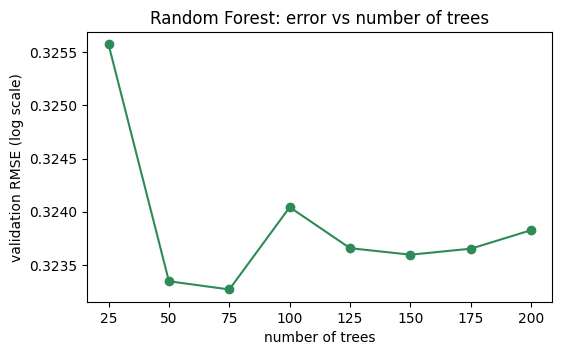

In [60]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest needs numbers: categories -> integer codes, NaN -> -1 (a fixed constant, so nothing is learned from the data)
X_rf, X_test_rf = X.copy(), X_test.copy()
for c in cat_cols:
    X_rf[c] = X_rf[c].cat.codes
    X_test_rf[c] = X_test_rf[c].cat.codes
X_rf, X_test_rf = X_rf.fillna(-1), X_test_rf.fillna(-1)

RF_TREES = 200
rf_watch = RandomForestRegressor(n_estimators=25, max_features=0.33, min_samples_leaf=5,
                                 warm_start=True, n_jobs=-1, random_state=SEED)
y_mode = y_target('log')
rf_curve = []
for n in tqdm(range(25, RF_TREES + 1, 25), desc='Random Forest - growing the forest'):
    rf_watch.set_params(n_estimators=n)
    rf_watch.fit(X_rf.iloc[hold_tr], y_mode[hold_tr])
    rf_curve.append((n, rmse(y_mode[hold_va], rf_watch.predict(X_rf.iloc[hold_va]))))

rf_curve = pd.DataFrame(rf_curve, columns=['n_trees', 'val_rmse'])
display(rf_curve.round(4).T)
plt.figure(figsize=(6, 3.5))
plt.plot(rf_curve['n_trees'], rf_curve['val_rmse'], marker='o', color='seagreen')
plt.xlabel('number of trees'); plt.ylabel('validation RMSE (log scale)'); plt.title('Random Forest: error vs number of trees')
plt.show()

The RMSE stabilized after around 50 trees, with little improvement from adding more trees. This suggests that fewer trees could reduce training time without much loss in performance.

###**5.3 Ridge** -The only thing to tune is the regularization strength `alpha`. Count-like features go through `log1p` before scaling.

In [61]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

def signed_log1p(a):
    return np.sign(a) * np.log1p(np.abs(a))

def make_ridge_prep():
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),      # median learned on the training rows only
                          ('log', FunctionTransformer(signed_log1p)),
                          ('scale', StandardScaler())]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

y_mode = y_target('log')
alpha_rows = []
for alpha in tqdm([1, 3, 10, 30, 100], desc='Ridge alpha check'):
    pipe = Pipeline([('prep', make_ridge_prep()), ('model', Ridge(alpha=alpha))])
    pipe.fit(X.iloc[hold_tr], y_mode[hold_tr])
    alpha_rows.append((alpha, rmse(y_mode[hold_va], pipe.predict(X.iloc[hold_va]))))

alpha_df = pd.DataFrame(alpha_rows, columns=['alpha', 'val_rmse_log'])
display(alpha_df)
RIDGE_ALPHA = float(alpha_df.sort_values('val_rmse_log').iloc[0]['alpha'])
print('Best alpha:', RIDGE_ALPHA)

Ridge alpha check:   0%|          | 0/5 [00:00<?, ?it/s]

,alpha,val_rmse_log
0,1,0.339992
1,3,0.339340
2,10,0.338697
3,30,0.338600
4,100,0.339611


Best alpha: 30.0


### 5.4 CatBoost

CatBoost is included as an additional tabular model beyond the core models. It is useful here because it handles categorical features directly and provides predictions from a different boosting implementation.


=== CatBoost, log target ===
0:	learn: 1.8528220	test: 1.8015243	best: 1.8015243 (0)	total: 50ms	remaining: 1m 39s
100:	learn: 0.2955298	test: 0.3470625	best: 0.3470625 (100)	total: 3.59s	remaining: 1m 7s
200:	learn: 0.2705198	test: 0.3359881	best: 0.3359873 (199)	total: 6.98s	remaining: 1m 2s
300:	learn: 0.2519526	test: 0.3317926	best: 0.3317926 (300)	total: 9.21s	remaining: 52s
400:	learn: 0.2382636	test: 0.3304886	best: 0.3304886 (400)	total: 11.5s	remaining: 45.7s
500:	learn: 0.2255073	test: 0.3294152	best: 0.3293871 (499)	total: 13.7s	remaining: 40.9s
600:	learn: 0.2148933	test: 0.3287196	best: 0.3287196 (600)	total: 16s	remaining: 37.3s
700:	learn: 0.2061872	test: 0.3286912	best: 0.3286141 (607)	total: 20.4s	remaining: 37.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3286140569
bestIteration = 607

Shrink model to first 608 iterations.
best iteration: 608

=== CatBoost, growth target ===
0:	learn: 0.3535707	test: 0.4246519	best: 0.4246519 (0)	total: 26m

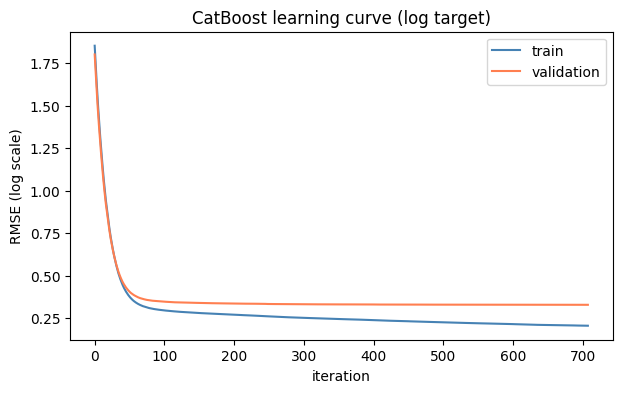

{'log': {'iters': 608}, 'growth': {'iters': 413}}


In [62]:
USE_CATBOOST = True

CB_CFG = {}
if USE_CATBOOST:
    try:
        from catboost import CatBoostRegressor
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'catboost'])
        from catboost import CatBoostRegressor

    # CatBoost takes categorical columns as plain text
    X_cb, X_test_cb = X.copy(), X_test.copy()
    for c in cat_cols:
        X_cb[c] = X_cb[c].astype(str).astype(object)
        X_test_cb[c] = X_test_cb[c].astype(str).astype(object)

    cb_curves = {}
    for mode in ['log', 'growth']:
        y_mode = y_target(mode)
        print(f'\n=== CatBoost, {mode} target ===')
        cb = CatBoostRegressor(iterations=2000, learning_rate=0.05, depth=6, loss_function='RMSE',
                               random_seed=SEED, early_stopping_rounds=100, verbose=100)
        cb.fit(X_cb.iloc[hold_tr], y_mode[hold_tr], cat_features=cat_cols,
               eval_set=(X_cb.iloc[hold_va], y_mode[hold_va]), use_best_model=True)
        CB_CFG[mode] = dict(iters=int(cb.get_best_iteration()) + 1)
        cb_curves[mode] = cb.get_evals_result()
        print('best iteration:', CB_CFG[mode]['iters'])

    plt.figure(figsize=(7, 4))
    ev = cb_curves['log']
    plt.plot(ev['learn']['RMSE'], label='train', color='steelblue')
    plt.plot(ev['validation']['RMSE'], label='validation', color='coral')
    plt.xlabel('iteration'); plt.ylabel('RMSE (log scale)'); plt.title('CatBoost learning curve (log target)')
    plt.legend(); plt.show()
    print(CB_CFG)

CatBoost stopped early because of overfitting detection, similar to LightGBM. This shows that additional iterations were not improving validation performance.

# 6. Model Comparison & Error Analysis ⚖️

All candidate models are evaluated with the same repeated 5-fold cross-validation and the same metrics. The primary question is: **which approach gives the lowest raw RMSE while remaining stable on the typical videos?**

In [63]:
def fit_predict_lgb(mode, X_fit, y_fit, X_pred, seed=SEED, iter_scale=1.0):
    cfg = LGB_CFG[mode]
    dtr = lgb.Dataset(X_fit, label=y_fit, categorical_feature=cat_cols)
    booster = lgb.train(lgb_params(cfg['lr'], seed), dtr, num_boost_round=max(1, int(cfg['iters'] * iter_scale)))
    return booster.predict(X_pred)

def fit_predict_rf(mode, X_fit, y_fit, X_pred, seed=SEED, iter_scale=1.0):
    rf = RandomForestRegressor(n_estimators=RF_TREES, max_features=0.33, min_samples_leaf=5,
                               n_jobs=-1, random_state=seed)
    rf.fit(X_fit, y_fit)
    return rf.predict(X_pred)

def fit_predict_ridge(mode, X_fit, y_fit, X_pred, seed=SEED, iter_scale=1.0):
    pipe = Pipeline([('prep', make_ridge_prep()), ('model', Ridge(alpha=RIDGE_ALPHA))])
    pipe.fit(X_fit, y_fit)
    return pipe.predict(X_pred)

def fit_predict_cat(mode, X_fit, y_fit, X_pred, seed=SEED, iter_scale=1.0):
    cb = CatBoostRegressor(iterations=max(1, int(CB_CFG[mode]['iters'] * iter_scale)), learning_rate=0.05, depth=6,
                           loss_function='RMSE', random_seed=seed, verbose=0)
    cb.fit(X_fit, y_fit, cat_features=cat_cols)
    return cb.predict(X_pred)

# model name -> (function, (train matrix, test matrix), which target versions to run)
MODELS = {
    'lgb':   (fit_predict_lgb,   (X, X_test),          ['log', 'growth']),
    'rf':    (fit_predict_rf,    (X_rf, X_test_rf),    ['log', 'growth']),
    'ridge': (fit_predict_ridge, (X, X_test),          ['log']),
}
if USE_CATBOOST:
    MODELS['cat'] = (fit_predict_cat, (X_cb, X_test_cb), ['log', 'growth'])

oof, oof_unclipped = {}, {}      # 'lgb_log' -> array (N_SEEDS, n_train_rows) of out-of-fold predicted views

In [64]:
for name, (fn, (Xm, _), modes) in MODELS.items():
    for mode in modes:
        key = f'{name}_{mode}'
        if key in oof:                      # already computed (lets you re-run this cell after switching CatBoost on)
            continue
        y_mode = y_target(mode)
        preds = np.zeros((N_SEEDS, len(Xm)))
        for s in range(N_SEEDS):
            for tr_i, va_i in tqdm(splits[s], desc=f'{key} | repeat {s + 1}/{N_SEEDS}', leave=False):
                p = fn(mode, Xm.iloc[tr_i], y_mode[tr_i], Xm.iloc[va_i])
                preds[s, va_i] = to_views(mode, p, base_train[va_i])
        oof_unclipped[key] = preds
        oof[key] = finalize(preds, last_train)
        print(f'{key:12s} done  | raw RMSE = {np.mean([score(p)["raw"] for p in oof[key]]):,.0f}')

lgb_log | repeat 1/2:   0%|          | 0/5 [00:00<?, ?it/s]

lgb_log | repeat 2/2:   0%|          | 0/5 [00:00<?, ?it/s]

lgb_log      done  | raw RMSE = 82,473


lgb_growth | repeat 1/2:   0%|          | 0/5 [00:00<?, ?it/s]

lgb_growth | repeat 2/2:   0%|          | 0/5 [00:00<?, ?it/s]

...

cat_log | repeat 2/2:   0%|          | 0/5 [00:00<?, ?it/s]

cat_log      done  | raw RMSE = 80,885


cat_growth | repeat 1/2:   0%|          | 0/5 [00:00<?, ?it/s]

cat_growth | repeat 2/2:   0%|          | 0/5 [00:00<?, ?it/s]

cat_growth   done  | raw RMSE = 80,686


### Ensemble strategy

The blends use a simple equal-weight average. Equal weights are intentionally used instead of fitting blend weights to the validation predictions, because the raw RMSE is dominated by a small number of viral videos and learned weights could overfit those observations.


In [65]:
def summarize(name, preds_by_repeat):
    df = pd.DataFrame([score(p) for p in preds_by_repeat])
    return {'model': name, 'raw_RMSE': df['raw'].mean(), 'raw_RMSE_sd': df['raw'].std(ddof=0),
            'log_RMSE': df['log'].mean(), 'raw_RMSE_without_top10': df['no_top10'].mean()}

def blend(members):
    return finalize(np.mean([oof[k] for k in members], axis=0), last_train)

BLEND_BASE = [k for k in ['lgb_log', 'lgb_growth', 'rf_log', 'rf_growth', 'ridge_log'] if k in oof]
BLEND_WITH_CAT = BLEND_BASE + [k for k in ['cat_log', 'cat_growth'] if k in oof]

rows = [summarize(k, v) for k, v in oof.items()]
rows.append(summarize('BLEND (lgb + rf + ridge)', blend(BLEND_BASE)))
if len(BLEND_WITH_CAT) > len(BLEND_BASE):
    rows.append(summarize('BLEND (lgb + rf + ridge + catboost)', blend(BLEND_WITH_CAT)))

results = pd.DataFrame(rows).sort_values('raw_RMSE').reset_index(drop=True)
display(results.style.format({'raw_RMSE': '{:,.0f}', 'raw_RMSE_sd': '{:,.0f}', 'log_RMSE': '{:.4f}',
                              'raw_RMSE_without_top10': '{:,.0f}'}))

,model,raw_RMSE,raw_RMSE_sd,log_RMSE,raw_RMSE_without_top10
0,BLEND (lgb + rf + ridge + catboost),"58,481","1,662",0.2885,"47,873"
1,BLEND (lgb + rf + ridge),"61,569","2,333",0.2885,"48,201"
2,rf_log,"74,140",563,0.2971,"55,826"
3,ridge_log,"77,629",274,0.3032,"51,108"
4,cat_growth,"80,686","1,998",0.2995,"48,624"
5,cat_log,"80,885","3,804",0.2986,"58,672"
6,lgb_log,"82,473","1,517",0.2947,"60,609"
7,rf_growth,"97,739","4,079",0.3122,"50,818"
8,lgb_growth,"130,557","11,763",0.3046,"62,407"


Ensembling improved performance by approximately 20% compared to the best single model (rf_log).

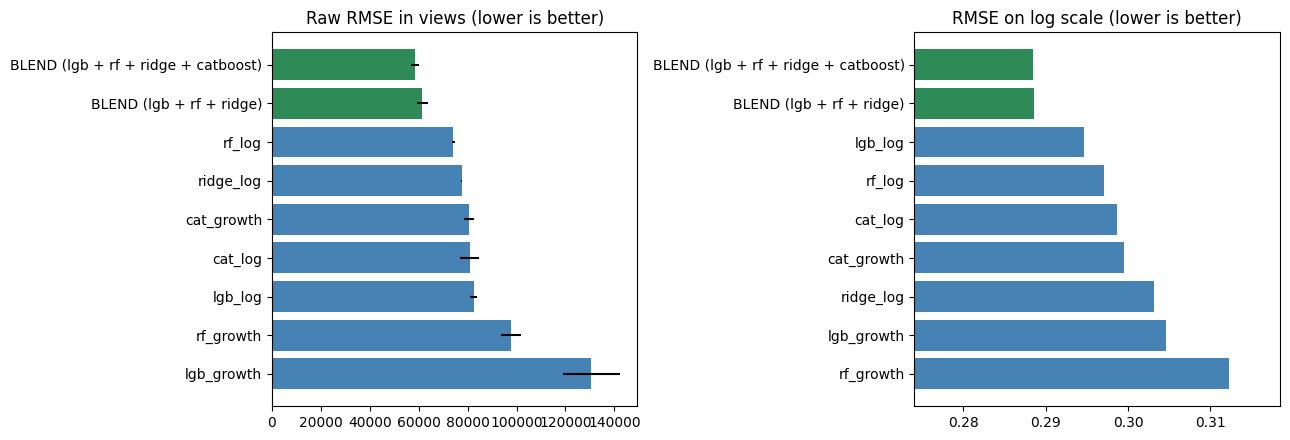

Best single model by raw RMSE: rf_log (74,140)
Best ensemble by raw RMSE: BLEND (lgb + rf + ridge + catboost) (58,481)
Ensemble improvement vs best single: 21.1%
Selection rule: choose the ensemble with the lowest raw RMSE because raw RMSE is the competition metric.


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
r = results.sort_values('raw_RMSE', ascending=False)
colors = ['seagreen' if m.startswith('BLEND') else 'steelblue' for m in r['model']]
axes[0].barh(r['model'], r['raw_RMSE'], xerr=r['raw_RMSE_sd'], color=colors)
axes[0].set_title('Raw RMSE in views (lower is better)')

r2 = results.sort_values('log_RMSE', ascending=False)
axes[1].barh(r2['model'], r2['log_RMSE'], color=['seagreen' if m.startswith('BLEND') else 'steelblue' for m in r2['model']])
axes[1].set_xlim(r2['log_RMSE'].min() * 0.95, r2['log_RMSE'].max() * 1.02)
axes[1].set_title('RMSE on log scale (lower is better)')
plt.tight_layout(); plt.show()

singles = results[~results['model'].str.startswith('BLEND')]
blends = results[results['model'].str.startswith('BLEND')]
best_single = singles.sort_values('raw_RMSE').iloc[0]
best_blend = blends.sort_values('raw_RMSE').iloc[0] if len(blends) else None

print(f"Best single model by raw RMSE: {best_single['model']} ({best_single['raw_RMSE']:,.0f})")
if best_blend is not None:
    improvement = 1 - best_blend['raw_RMSE'] / best_single['raw_RMSE']
    print(f"Best ensemble by raw RMSE: {best_blend['model']} ({best_blend['raw_RMSE']:,.0f})")
    print(f"Ensemble improvement vs best single: {improvement:.1%}")
    print("Selection rule: choose the ensemble with the lowest raw RMSE because raw RMSE is the competition metric.")

### How to interpret the results

- **Raw RMSE:** primary metric for the competition. Lower is better.
- **Log RMSE:** supporting diagnostic for performance across the wider distribution.
- **RMSE without top 10:** shows performance on the bulk of videos without the most extreme viral cases.
- **RMSE SD:** shows how much the score changes across repeated CV runs.

A model should not be selected from one metric in isolation, but **raw RMSE is the final decision criterion because it is the Kaggle metric**.

### Error Analysis

We now look at where the best model is actually wrong, not just how wrong on average. Using the out-of-fold predictions from the best blend, we check: (1) the largest individual errors, (2) whether the model tends to over- or under-predict, and (3) whether errors are concentrated in a particular topic.

Overall bias (mean residual): -1,194  (under-predicting on average)
Share of videos over-predicted: 68.3%

Top 10 largest absolute errors:


,video_id,topic,actual,predicted,residual
8643,7418019116902075678,Dance_Music,4110239.0,2.394741e+06,-1.715498e+06
3424,7405034512733850926,Beauty_Fashion,5478572.0,4.015363e+06,-1.463209e+06
8511,7404285432810458414,Shopping_Products,1821615.0,4.034413e+05,-1.418174e+06
4713,7434730150987599134,Others,5279577.0,3.893955e+06,-1.385622e+06
8198,7393462047465475374,Dance_Music,1863805.0,3.095542e+06,1.231737e+06
37,7398371860049661214,Beauty_Fashion,1888001.0,6.973724e+05,-1.190629e+06
3104,7425058770918591790,Lifestyle,1534930.0,4.489123e+05,-1.086018e+06
8597,7411595286088256799,Lifestyle,1093110.0,8.010692e+04,-1.013003e+06
9960,7423947121071623467,Lifestyle,1170372.0,2.148527e+06,9.781553e+05
11115,7433609207527574826,Others,16310546.0,1.536830e+07,-9.422456e+05



Mean absolute % error by topic (videos with actual >= 100 views, to avoid tiny-denominator noise):


,mean_abs_pct_error
topic,
Shopping_Products,0.139
Cooking_Food,0.119
Beauty_Fashion,0.119
Sports_Fitness,0.116
Others,0.114
Lifestyle,0.113
Dance_Music,0.108
Movies_TV_Books,0.106
Life_hacks_Personal_growth,0.093


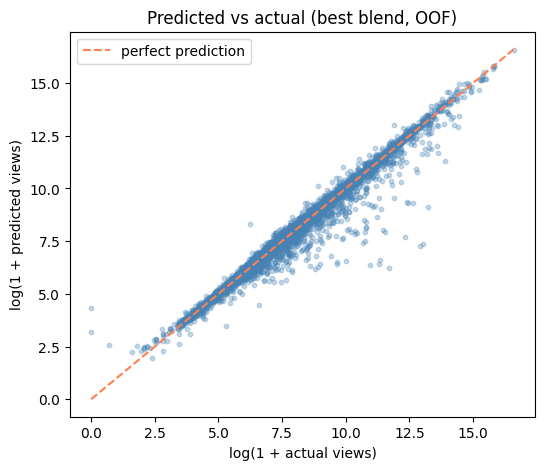

In [67]:
best_key = blends.sort_values('raw_RMSE').iloc[0]['model']
best_members = BLEND_WITH_CAT if 'catboost' in best_key else BLEND_BASE
best_pred = blend(best_members).mean(axis=0) if blend(best_members).ndim > 1 else blend(best_members)
# blend() already averages over repeats via oof[k], which itself is shape (N_SEEDS, n_rows) -> reduce seeds too
best_pred = np.mean([finalize(np.mean([oof_unclipped[k][s] for k in best_members], axis=0), last_train)
                      for s in range(N_SEEDS)], axis=0)

err = pd.DataFrame({
    'video_id': train_feat['video_id'].values,
    'topic': train_feat['topic'].values,
    'actual': y_raw,
    'predicted': best_pred,
})
err['residual'] = err['predicted'] - err['actual']
err['abs_error'] = err['residual'].abs()
err['pct_error'] = err['residual'] / err['actual'].replace(0, np.nan)

print(f"Overall bias (mean residual): {err['residual'].mean():,.0f}  "
      f"({'over' if err['residual'].mean() > 0 else 'under'}-predicting on average)")
print(f"Share of videos over-predicted: {(err['residual'] > 0).mean():.1%}")

print('\nTop 10 largest absolute errors:')
display(err.sort_values('abs_error', ascending=False).head(10)
        [['video_id', 'topic', 'actual', 'predicted', 'residual']])

print('\nMean absolute % error by topic (videos with actual >= 100 views, to avoid tiny-denominator noise):')
display(err[err['actual'] >= 100].groupby('topic')['pct_error'].apply(lambda s: s.abs().mean())
        .sort_values(ascending=False).round(3).to_frame('mean_abs_pct_error'))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np.log1p(err['actual']), np.log1p(err['predicted']), alpha=0.3, s=10, color='steelblue')
lims = [0, np.log1p(err['actual'].max())]
ax.plot(lims, lims, color='coral', linestyle='--', label='perfect prediction')
ax.set_xlabel('log(1 + actual views)'); ax.set_ylabel('log(1 + predicted views)')
ax.set_title('Predicted vs actual (best blend, OOF)')
ax.legend(); plt.show()

The model is fairly well-calibrated on typical videos (mean_abs_pct_error stays around 10–14% across every topic), but it systematically under-predicts the biggest viral outliers — 9 of the top 10 largest errors are under-predictions, including the single largest training video (16.3M actual vs 1.5M predicted). This is expected: a log-target model is pulled toward the bulk of the data, so it's conservative exactly where the competition metric (raw RMSE) is most sensitive. This is the main remaining risk for the leaderboard score, not any particular topic or feature gap.

### Experiment 1: clipping predictions

Because cumulative views should not decrease, predictions are clipped so they cannot fall below the last observed view count. We compare the raw RMSE before and after clipping to verify that this constraint is useful rather than assuming it.

In [68]:
for key in ['lgb_log', 'lgb_growth']:
    raw_before = np.mean([score(np.clip(p, 0, None))['raw'] for p in oof_unclipped[key]])
    raw_after = np.mean([score(p)['raw'] for p in oof[key]])
    print(f'{key:12s} raw RMSE without clipping: {raw_before:>10,.0f}   with clipping: {raw_after:>10,.0f}')

lgb_log      raw RMSE without clipping:    151,342   with clipping:     82,473
lgb_growth   raw RMSE without clipping:    130,649   with clipping:    130,557


Clipping significantly improved the LightGBM result, reducing the log RMSE from 151,342 to 82,473 (about 45%).

### Experiment 2: creator-grouped validation

We compare the main random K-fold validation with GroupKFold by creator. The grouped split is deliberately stricter: it asks how well the model works for creators that were not seen during training. The competition test set has high creator overlap, so this is treated as a robustness check rather than the primary validation scheme.

In [69]:
grp_pred = np.zeros(len(X))
y_mode = y_target('log')
for tr_i, va_i in tqdm(list(GroupKFold(5).split(X, groups=train_feat['author_id'])), desc='GroupKFold check', leave=False):
    p = fit_predict_lgb('log', X.iloc[tr_i], y_mode[tr_i], X.iloc[va_i])
    grp_pred[va_i] = to_views('log', p, base_train[va_i])
grp = score(finalize(grp_pred, last_train))
rnd = summarize('lgb_log', oof['lgb_log'])
print(f"random 5-fold : log RMSE {rnd['log_RMSE']:.4f} | raw RMSE {rnd['raw_RMSE']:,.0f}")
print(f"grouped 5-fold: log RMSE {grp['log']:.4f} | raw RMSE {grp['raw']:,.0f}")

GroupKFold check:   0%|          | 0/5 [00:00<?, ?it/s]

random 5-fold : log RMSE 0.2947 | raw RMSE 82,473
grouped 5-fold: log RMSE 0.3085 | raw RMSE 81,141


### Validation insight

The random and creator-grouped results answer different questions. Random K-fold is the closer match to the competition test structure because most test creators are already represented in training. GroupKFold is intentionally harder and is used only to check whether performance depends heavily on creator overlap.


### Feature importance insight

Feature importance helps explain which engineered signals the LightGBM model uses most. In this problem, early engagement level and engagement dynamics are expected to be especially informative because they describe how quickly a video is already accumulating attention.

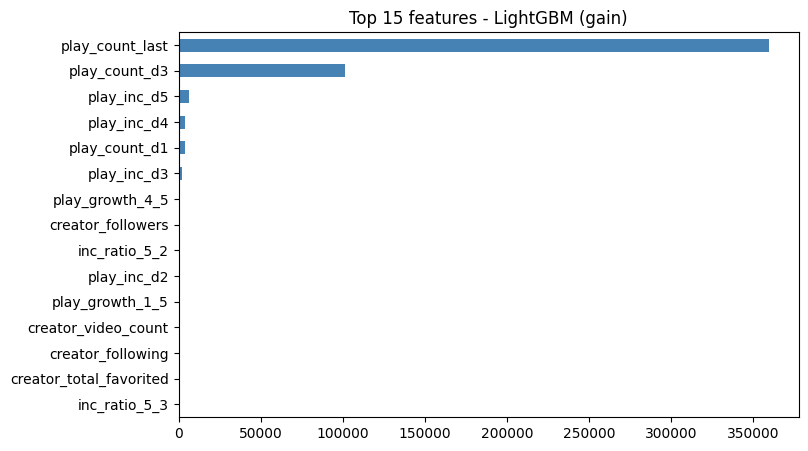

In [70]:
imp = pd.Series(lgb_watch.feature_importance(importance_type='gain'), index=X.columns).sort_values(ascending=False)
imp.head(15).plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Top 15 features - LightGBM (gain)')
plt.gca().invert_yaxis()
plt.show()

Because play_count_last and play_count_d3 are two snapshots of the same cumulative count, LightGBM resolves most of the target with just those two splits — so gain-based importance makes it look like nothing else matters

# 7. Final Model & Kaggle Submission ✅

The final ensemble is selected **automatically from the validation table using raw RMSE**, the competition metric. This prevents the notebook from depending on a manual model choice.

Every selected model is then retrained on the full training data before predicting the hidden test set. The submission is checked against the required sample-submission IDs and saved as `submission.csv`.

In [71]:
# Select the best available ensemble by the competition metric: raw RMSE.
blend_rows = results[results['model'].str.startswith('BLEND')].sort_values('raw_RMSE')
if len(blend_rows):
    best_blend_name = blend_rows.iloc[0]['model']
    FINAL_MEMBERS = BLEND_WITH_CAT if 'catboost' in best_blend_name else BLEND_BASE
else:
    best_single_name = results.iloc[0]['model']
    FINAL_MEMBERS = [best_single_name]

print('Final ensemble:', FINAL_MEMBERS)

test_views = {}
for key in tqdm(FINAL_MEMBERS, desc='Training final models on the full training set'):
    name, mode = key.split('_')
    fn, (Xm_train, Xm_test), _ = MODELS[name]
    p = fn(mode, Xm_train, y_target(mode), Xm_test, iter_scale=1.1)
    test_views[key] = to_views(mode, p, base_test)

final_views = finalize(np.mean([test_views[k] for k in FINAL_MEMBERS], axis=0), last_test)

submission = pd.DataFrame({'video_id': test_feat['video_id'].values,
                           'target_day30_views': np.round(final_views).astype(np.int64)})
# Match the sample_submission order and video_id list exactly.
submission = sample_submission[['video_id']].merge(submission, on='video_id', how='left')

assert len(submission) == len(sample_submission)
assert submission['video_id'].equals(sample_submission['video_id'])
assert submission['target_day30_views'].notna().all()
submission['target_day30_views'] = submission['target_day30_views'].astype(np.int64)
assert (submission['target_day30_views'] >= 0).all()
submission.to_csv('submission.csv', index=False)

print('Submission shape:', submission.shape)
display(submission.head())

Final ensemble: ['lgb_log', 'lgb_growth', 'rf_log', 'rf_growth', 'ridge_log', 'cat_log', 'cat_growth']


Training final models on the full training set:   0%|          | 0/7 [00:00<?, ?it/s]

Submission shape: (3001, 2)


,video_id,target_day30_views
0,7400582591771938090,249
1,7403167206978374958,385
2,7435124823820356906,2131
3,7409800970143714606,289
4,7410935177553333550,261


### Final prediction sanity check

Before submitting, we compare the prediction distribution with the training target distribution and verify that predictions are non-negative and are not below the last observed views. This is a final guard against implausible or unstable predictions.

In [72]:
q = [0.1, 0.5, 0.9, 0.99, 1.0]
display(pd.DataFrame({'train target': train['target_day30_views'].quantile(q).values,
                      'test prediction': submission['target_day30_views'].quantile(q).values},
                     index=[f'{int(p * 100)}%' for p in q]).round(0))

below_last = submission['target_day30_views'].values < np.floor(last_test)
print('Minimum prediction:', submission['target_day30_views'].min())
print('Predictions below last known views:', int(below_last.sum()))
assert not below_last.any()

,train target,test prediction
10%,247.0,251.0
50%,668.0,693.0
90%,21730.0,19517.0
99%,544055.0,545202.0
100%,16310546.0,6086666.0


Minimum prediction: 12
Predictions below last known views: 0


# 8. Final Summary

- **Objective:** predict cumulative Day 30 views using only allowed historical information.
- **Data handling:** engagement coverage was checked carefully because Day 0 is missing for many videos; features therefore use Days 1–5 and the last available day.
- **Feature engineering:** early engagement levels, trends, growth features, creator statistics, video metadata, and interaction ratios were used.
- **Target strategy:** both log-target and growth-target formulations were tested to handle the highly skewed view distribution.
- **Validation:** repeated random 5-fold CV is the main evaluation because the test set has substantial creator overlap; GroupKFold is included as a robustness check.
- **Models:** LightGBM, Random Forest, Ridge, and CatBoost were compared.
- **Ensembling:** equal-weight blends were tested, and the final blend is selected automatically by the lowest raw CV RMSE.
- **Risk control:** predictions are constrained by the cumulative nature of views, reducing harmful under-predictions and unstable extremes.
- **Submission:** the final predictions are checked against the required format and saved to `submission.csv`.

**Main takeaway:** the final model is chosen from evidence in cross-validation rather than from a single model assumption.